# Part 1: PTQ and QAT with `torchao` (VGG-11 on CIFAR-100)

This notebook implements the tasks for Part 1 of the assignment. We will:
1.  Establish a baseline FP32 **VGG-11** model and its accuracy on **CIFAR-100**.
2.  Apply **Post-Training Quantization (PTQ)** for `fp16`, `bf16`, `int8`, and `int4`.
3.  Apply **Quantization-Aware Training (QAT)** for `bf16`, `int8`, and `int4` to recover performance.
4.  Compare the results.

## 0. Setup and Installs

First, let's install the necessary libraries.

In [1]:
# !pip uninstall -y torchao
# !pip install torchao==0.13.0
# !pip install fbgemm-gpu fbgemm-gpu-genai

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import vgg11, VGG11_Weights
import copy
import time
import json
from torchao.quantization.qat.api import QATConfig

# # Import torchao (Fix for v0.13.0)
from torchao.quantization import (
    Int8WeightOnlyConfig,
    Int4WeightOnlyConfig,
    Int8DynamicActivationInt8WeightConfig,
    Int8DynamicActivationInt4WeightConfig,
    quantize_,
)

# Check versions and availability
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch Version: 2.6.0+cu126
CUDA Available: True
Using device: cuda


## 1. Establish FP32 Baseline (VGG-11 / CIFAR-100)

First, we define our helper functions to load the VGG-11 model and CIFAR-100 dataset. Then we'll fine-tune the model to create our FP32 baseline.

In [2]:
def get_model(pretrained=True):
    """Loads a VGG-11 model modified for CIFAR-100."""
    weights = VGG11_Weights.IMAGENET1K_V1 if pretrained else None
    model = vgg11(weights=weights)
    
    # VGG models have a 'classifier' block
    # Get the number of input features for the last layer
    num_ftrs = model.classifier[6].in_features
    
    # Replace the last layer with a new one for CIFAR-100 (100 classes)
    model.classifier[6] = nn.Linear(num_ftrs, 100)
    
    return model.to(device)

def get_dataloaders(batch_size=32):
    """Get CIFAR-100 train and test dataloaders."""
    # VGG-11 also expects 224x224 images
    transform = transforms.Compose([
        transforms.Resize(224), 
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    # --- Use full dataset for real results ---
    # For demo, we use subsets
    # ...
    train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
    # train_subset = torch.utils.data.Subset(train_set, range(5000)) # 5k samples for training demo
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True) # Use train_set

    test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
    # test_subset = torch.utils.data.Subset(test_set, range(1000)) # 1k samples for testing demo
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False) # Use test_set
    # ...
    
    return train_loader, test_loader

def evaluate(model, test_loader, use_autocast=False, dtype=torch.float16):
    """Evaluates the model's accuracy on the test loader."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            if use_autocast:
                # Use the new torch.amp.autocast API
                with torch.amp.autocast(device_type=device.type, dtype=dtype):
                    outputs = model(images)
            else:
                outputs = model(images)
                
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

# Get data
train_loader, test_loader = get_dataloaders()
print("CIFAR-100 Dataloaders ready.")

CIFAR-100 Dataloaders ready.


In [3]:
print("Fine-tuning FP32 VGG-11 model on CIFAR-100 to create a baseline...")

model_fp32 = get_model(pretrained=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_fp32.parameters(), lr=0.001, momentum=0.9)

num_epochs_baseline = 10 
model_fp32.train()
for epoch in range(num_epochs_baseline):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_fp32(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs_baseline}, Loss: {running_loss / len(train_loader):.3f}")

print("Finished fine-tuning.")

# Save this as our single source of truth
baseline_model_fp32 = copy.deepcopy(model_fp32)

# Evaluate and store baseline accuracy
baseline_accuracy = evaluate(baseline_model_fp32, test_loader)
print(f"\nBaseline FP32 VGG-11 Accuracy: {baseline_accuracy:.2f}%")

# This dictionary will store all our results
results = {
    'fp32': {'ptq_accuracy': baseline_accuracy, 'qat_accuracy': 'N/A'}
}

Fine-tuning FP32 VGG-11 model on CIFAR-100 to create a baseline...
Epoch 1/10, Loss: 1.915
Epoch 2/10, Loss: 1.126
Epoch 3/10, Loss: 0.859
Epoch 4/10, Loss: 0.658
Epoch 5/10, Loss: 0.504
Epoch 6/10, Loss: 0.375
Epoch 7/10, Loss: 0.275
Epoch 8/10, Loss: 0.207
Epoch 9/10, Loss: 0.153
Epoch 10/10, Loss: 0.125
Finished fine-tuning.

Baseline FP32 VGG-11 Accuracy: 74.82%


## 2. Post-Training Quantization (PTQ)

Now we apply PTQ to our `baseline_model_fp32` (the VGG-11 we just trained).

### 2a. PTQ for `fp16` and `bf16`

This is a simple type-cast. We'll use `autocast` during evaluation.

In [4]:
print("--- Running PTQ for fp16 and bf16 ---")

# --- fp16 --- 
model_fp16_ptq = copy.deepcopy(baseline_model_fp32).half()
acc_fp16_ptq = evaluate(model_fp16_ptq, test_loader, use_autocast=True, dtype=torch.float16)
print(f"PTQ fp16 Accuracy: {acc_fp16_ptq:.2f}%")
results['fp16'] = {'ptq_accuracy': acc_fp16_ptq}

# --- bf16 --- 
print("\nRunning PTQ for bf16...")
# Note: bf16 requires Ampere or newer GPUs
try:
    model_bf16_ptq = copy.deepcopy(baseline_model_fp32).to(torch.bfloat16)
    acc_bf16_ptq = evaluate(model_bf16_ptq, test_loader, use_autocast=True, dtype=torch.bfloat16)
    print(f"PTQ bf16 Accuracy: {acc_bf16_ptq:.2f}%")
    results['bf16'] = {'ptq_accuracy': acc_bf16_ptq}
except Exception as e:
    print(f"Could not run bf16 test (likely unsupported hardware): {e}")
    results['bf16'] = {'ptq_accuracy': 'N/A'}

--- Running PTQ for fp16 and bf16 ---
PTQ fp16 Accuracy: 74.81%

Running PTQ for bf16...
PTQ bf16 Accuracy: 74.77%


### 2b. PTQ for `int8` and `int4` (with `torchao`)

We use `torchao.quantization.quantize_` to apply weight-only quantization in-place.

In [5]:
print("\n--- Running PTQ for int8 and int4 ---")

# --- int8 --- 
# Explicitly cast to fp32. This works fine for int8.
model_int8_ptq = copy.deepcopy(baseline_model_fp32).to(torch.float32) 
int8_config = Int8WeightOnlyConfig()
quantize_(model_int8_ptq, int8_config)

acc_int8_ptq = evaluate(model_int8_ptq, test_loader)
print(f"PTQ int8 Accuracy: {acc_int8_ptq:.2f}%")
results['int8'] = {'ptq_accuracy': acc_int8_ptq}

# --- int4 --- 
# FIXED: Cast to bfloat16 to match the torchao int4 backend's expectation
print("\nCasting model to bfloat16 for int4 PTQ...")
try:
    model_int4_ptq = copy.deepcopy(baseline_model_fp32).to(torch.bfloat16)
    int4_config = Int4WeightOnlyConfig(group_size=128)
    quantize_(model_int4_ptq, int4_config)

    # FIXED: We must also evaluate int4 PTQ with bfloat16 autocast
    acc_int4_ptq = evaluate(model_int4_ptq, test_loader, use_autocast=True, dtype=torch.bfloat16)
    print(f"PTQ int4 Accuracy: {acc_int4_ptq:.2f}%")
    results['int4'] = {'ptq_accuracy': acc_int4_ptq}

except Exception as e:
    print(f"Could not run int4 PTQ (likely bf16 unsupported hardware): {e}")
    if 'int4' not in results:
        results['int4'] = {}
    results['int4']['ptq_accuracy'] = 'N/A'


--- Running PTQ for int8 and int4 ---
PTQ int8 Accuracy: 74.79%

Casting model to bfloat16 for int4 PTQ...
PTQ int4 Accuracy: 74.85%


## 5. Save Progress

Save the baseline model's state_dict and the results dictionary to disk.


In [7]:
print("\n--- Saving progress ---")

# 1. Save the baseline model's weights (the state_dict)
# This is the recommended way to save a model in PyTorch
torch.save(baseline_model_fp32.state_dict(), "baseline_model_fp32.pth")
print("Saved baseline model state to 'baseline_model_fp32.pth'")

# 2. Save the results dictionary as a JSON file
with open("quantization_results_part1.json", 'w') as f:
    json.dump(results, f, indent=2)
print("Saved PTQ results to 'quantization_results_part1.json'")


--- Saving progress ---
Saved baseline model state to 'baseline_model_fp32.pth'
Saved PTQ results to 'quantization_results_part1.json'


# Resume Work on Part 3 (Mixed Precision)

Load the saved baseline model and results from Part 1.

In [3]:
import torch
import torch.nn as nn
import json
import copy
from torchvision.models import vgg11

# --- You will need these helper functions again ---
# Make sure this 'get_model' function is defined in your script

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_model(pretrained=True):
    """Loads a VGG-11 model modified for CIFAR-100."""
    # Note: When loading a saved state_dict, pretrained=False is fine
    # because we are about to overwrite the weights anyway.
    weights = VGG11_Weights.IMAGENET1K_V1 if pretrained else None
    model = vgg11(weights=weights)
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, 100)
    return model.to(device)

# --- End of helper functions ---


# 1. Load the results dictionary
with open("quantization_results_part1.json", 'r') as f:
    results = json.load(f)

print("--- Loaded previous results ---")
print(json.dumps(results, indent=2))


# 2. Load the baseline model
#    First, create an instance of the model architecture
baseline_model_fp32 = get_model(pretrained=False)

#    Next, load the saved weights (the state_dict) into it
baseline_model_fp32.load_state_dict(torch.load("baseline_model_fp32.pth"))
baseline_model_fp32.to(device)
baseline_model_fp32.eval() # Set it to eval mode (good practice after loading)
    
print("\n--- Successfully reloaded baseline_model_fp32 ---")
print("You are ready to continue with QAT or Mixed-Precision.")

# You will also need your dataloaders for the next steps
# (Copy the get_dataloaders() function and call it)
train_loader, test_loader = get_dataloaders()
print("Dataloaders ready.")

--- Loaded previous results ---
{
  "fp32": {
    "ptq_accuracy": 74.82,
    "qat_accuracy": "N/A"
  },
  "fp16": {
    "ptq_accuracy": 74.81
  },
  "bf16": {
    "ptq_accuracy": 74.77
  },
  "int8": {
    "ptq_accuracy": 74.79
  },
  "int4": {
    "ptq_accuracy": 74.85
  }
}

--- Successfully reloaded baseline_model_fp32 ---
You are ready to continue with QAT or Mixed-Precision.
Dataloaders ready.


## 3. Quantization-Aware Training (QAT)

Now, we'll fine-tune the model *with quantization effects* to help it recover lost accuracy. We always start from the `baseline_model_fp32`.

### 3a. QAT for `bf16` (Mixed-Precision Training)

We fine-tune 5 epochs using `torch.cuda.amp.autocast` and `GradScaler`. This is standard mixed-precision training.

In [ ]:
print("--- Running QAT for bf16 (Mixed Precision) ---")
try:
    model_bf16_qat = copy.deepcopy(baseline_model_fp32)
    optimizer = optim.SGD(model_bf16_qat.parameters(), lr=0.0001, momentum=0.9) # Lower LR for fine-tuning
    criterion = nn.CrossEntropyLoss()
    
    device_str = "cuda" if torch.cuda.is_available() else "cpu"
    scaler = torch.amp.GradScaler(device_str) # non depricated

    num_qat_epochs = 5
    acc = 'N/A' # Default in case of error

    for epoch in range(num_qat_epochs):
        model_bf16_qat.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()

            # FIXED: Correct autocast arguments
            with torch.amp.autocast(device_type=device.type, dtype=torch.bfloat16):
                outputs = model_bf16_qat(inputs)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        
        # Evaluate after each epoch
        acc = evaluate(model_bf16_qat, test_loader, use_autocast=True, dtype=torch.bfloat16)
        print(f"Epoch {epoch+1}/{num_qat_epochs}, bf16 QAT Accuracy: {acc:.2f}%")

    if 'bf16' not in results:
        results['bf16'] = {} # Ensure key exists
    results['bf16']['qat_accuracy'] = acc
    print(f"Final bf16 QAT Accuracy: {acc:.2f}%")

except Exception as e:
    print(f"Could not run bf16 QAT (likely unsupported hardware): {e}")
    if 'bf16' not in results:
        results['bf16'] = {}
    results['bf16']['qat_accuracy'] = 'N/A'

--- Running QAT for bf16 (Mixed Precision) ---


C:\Users\mahsa\AppData\Local\Temp\ipykernel_21432\474378180.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/5, bf16 QAT Accuracy: 77.14%
Epoch 2/5, bf16 QAT Accuracy: 77.12%
Epoch 3/5, bf16 QAT Accuracy: 77.24%
Epoch 4/5, bf16 QAT Accuracy: 77.23%
Epoch 5/5, bf16 QAT Accuracy: 77.62%
Final bf16 QAT Accuracy: 77.62%


### 3b. QAT for `fp16` (Mixed-Precision Training)

We fine-tune for 5 epochs using `torch.cuda.amp.autocast` and `GradScaler`. This is standard mixed-precision training.

In [18]:
print("--- Running QAT for fp16 (Mixed Precision) ---")
try:
    model_fp16_qat = copy.deepcopy(baseline_model_fp32)
    optimizer = optim.SGD(model_fp16_qat.parameters(), lr=0.0001, momentum=0.9) # Lower LR for fine-tuning
    criterion = nn.CrossEntropyLoss()
    
    device_str = "cuda" if torch.cuda.is_available() else "cpu"
    scaler = torch.amp.GradScaler(device_str) # non depricated

    num_qat_epochs = 5
    acc = 'N/A' # Default in case of error

    for epoch in range(num_qat_epochs):
        model_fp16_qat.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()

            # FIXED: Correct autocast arguments
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16):
                outputs = model_fp16_qat(inputs)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        
        # Evaluate after each epoch
        acc = evaluate(model_fp16_qat, test_loader, use_autocast=True, dtype=torch.float16)
        print(f"Epoch {epoch+1}/{num_qat_epochs}, fp16 QAT Accuracy: {acc:.2f}%")

    if 'fp16' not in results:
        results['fp16'] = {} # Ensure key exists
    results['fp16']['qat_accuracy'] = acc
    print(f"Final fp16 QAT Accuracy: {acc:.2f}%")

except Exception as e:
    print(f"Could not run fp16 QAT (likely unsupported hardware): {e}")
    if 'fp16' not in results:
        results['fp16'] = {}
    results['fp16']['qat_accuracy'] = 'N/A'

--- Running QAT for fp16 (Mixed Precision) ---
Epoch 1/5, fp16 QAT Accuracy: 76.95%
Epoch 2/5, fp16 QAT Accuracy: 77.21%
Epoch 3/5, fp16 QAT Accuracy: 77.54%
Epoch 4/5, fp16 QAT Accuracy: 77.26%
Epoch 5/5, fp16 QAT Accuracy: 77.23%
Final fp16 QAT Accuracy: 77.23%


### 3c. QAT for `int4` (with `torchao`)

We repeat the process for `int4`. This is where QAT typically shows the most significant benefit, as `int4` PTQ often causes a large accuracy drop.

In [4]:
print("\n--- Running QAT for int4 ---")
try:
    # Cast to bfloat16 for the int4 backend
    model_int4_qat = copy.deepcopy(baseline_model_fp32).to(torch.bfloat16)

    # 1. Prepare for QAT
    # Use the config that handles BOTH activations (int8) and weights (int4)
    base_quant_config_int4 = Int8DynamicActivationInt4WeightConfig() 
    
    qat_config_int4 = QATConfig(base_quant_config_int4)
    quantize_(model_int4_qat, qat_config_int4) # Default step is "prepare"
    print("Model prepared for int4 QAT.")

    # 2. Fine-tune
    optimizer = optim.SGD(model_int4_qat.parameters(), lr=0.0001, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    
    # Get the device string 'cuda' or 'cpu'
    device_str = "cuda" if torch.cuda.is_available() else "cpu"

    num_qat_epochs_int4 = 10 
    print(f"Starting int4 QAT fine-tuning for {num_qat_epochs_int4} epochs...")

    for epoch in range(num_qat_epochs_int4):
        model_int4_qat.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Use autocast for the bf16 model
            with torch.amp.autocast(device_type=device_str, dtype=torch.bfloat16):
                outputs = model_int4_qat(inputs)
                loss = criterion(outputs, labels)
            
            # Note: GradScaler is not typically needed here because QAT simulates
            # quantization, but the backward pass is full-precision (or bf16).
            # If you were using fp16, you would use GradScaler.
            # For bf16, direct .backward() is standard.
            loss.backward()
            optimizer.step()
        
        # Use autocast for evaluation
        # int4: uses bf16-packed kernels → autocast required
        acc_simulated = evaluate(model_int4_qat, test_loader, use_autocast=True, dtype=torch.bfloat16)
        print(f"Epoch {epoch+1}/{num_qat_epochs_int4}, Simulated int4 QAT Accuracy: {acc_simulated:.2f}%")

    print("Finished int4 QAT fine-tuning.")

    # 3. Convert
    model_int4_qat.eval()

    # Use the standard torch.ao.quantization.convert function
    torch.ao.quantization.convert(model_int4_qat, inplace=True) 
    
    print("Model converted for final int4 inference.")

    # 4. Evaluate
    # Use autocast for final evaluation
    final_int4_qat_acc = evaluate(model_int4_qat, test_loader, use_autocast=True, dtype=torch.bfloat16)
    print(f"Final Converted int4 QAT Accuracy: {final_int4_qat_acc:.2f}%")

    if 'int4' not in results:
        results['int4'] = {}
    results['int4']['qat_accuracy'] = final_int4_qat_acc

except Exception as e:
    print(f"Could not run int4 QAT: {e}")
    if 'int4' not in results:
        results['int4'] = {}
    results['int4']['qat_accuracy'] = 'N/A'


--- Running QAT for int4 ---
Model prepared for int4 QAT.
Starting int4 QAT fine-tuning for 10 epochs...


KeyboardInterrupt: 

### 3d. QAT for `int8` (Standard PyTorch QAT)

Using standard PyTorch QAT instead of torchao since torchao's int8 QAT config has compatibility issues.
The flow is:
1.  **Prepare:** Set qconfig and call `prepare_qat()` to insert fake-quantization operators.
2.  **Fine-tune:** Train the model. The forward pass simulates quantization.
3.  **Convert:** Replace fake-quant ops with real integer ops for inference.

In [4]:
# for int8 QAT
def evaluate(model, test_loader, use_autocast=False, dtype=torch.float16):
    """Evaluates the model's accuracy on the test loader."""
    model.eval()
    
    # --- START OF FIX ---
    # Determine the device from the model itself, not a global variable
    try:
        model_device = next(model.parameters()).device
    except StopIteration:
        # Handle models with no parameters (if any)
        model_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(model_device)
    # --- END OF FIX ---

    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            # --- START OF FIX ---
            # Move data to the model's device
            images, labels = images.to(model_device), labels.to(model_device)
            # --- END OF FIX ---
            
            if use_autocast:
                # Use the new torch.amp.autocast API
                with torch.amp.autocast(device_type=model_device.type, dtype=dtype):
                    outputs = model(images)
            else:
                outputs = model(images)
                
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

In [5]:
print("\n--- Running QAT for int8 (Standard PyTorch Flow) ---")
try:
    # 1. Create a fresh model copy
    model_int8_qat = copy.deepcopy(baseline_model_fp32)
    
    # Set the model to training mode BEFORE preparing
    model_int8_qat.train()
    
    # 2. Prepare for QAT (Standard PyTorch Method)
    # We are not using torchao's QATConfig here, as it fails.
    # Instead, we use the default PyTorch QAT configuration.
    
    # 'fbgemm' is the correct backend for x86 CPUs/NVIDIA GPUs
    model_int8_qat.qconfig = torch.ao.quantization.get_default_qat_qconfig('qnnpack')
    
    # This function replaces torchao's quantize_() for preparation
    torch.ao.quantization.prepare_qat(model_int8_qat, inplace=True)
    
    print("Model prepared for int8 QAT.")

    # 3. Fine-tune (This part is identical to your code)
    optimizer = optim.SGD(model_int8_qat.parameters(), lr=0.0001, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    device_str = "cuda" if torch.cuda.is_available() else "cpu"
    num_qat_epochs_int8 = 1
    
    print(f"Starting int8 QAT fine-tuning for {num_qat_epochs_int8} epochs...")
    for epoch in range(num_qat_epochs_int8):
        model_int8_qat.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model_int8_qat(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
        
        acc_simulated = evaluate(model_int8_qat, test_loader)
        print(f"Epoch {epoch+1}/{num_qat_epochs_int8}, Simulated int8 QAT Accuracy: {acc_simulated:.2f}%")

    print("Finished int8 QAT fine-tuning.")

    # 4. Convert (This part is identical to your working int4 code)
    model_int8_qat.eval()
    torch.ao.quantization.convert(model_int8_qat, inplace=True) 
    print("Model converted for final int8 inference.")

    # --- ADD THIS LINE ---
    # The converted int8 model must run on the CPU
    model_int8_qat.to('cpu')
    print("Moved converted int8 model to CPU for evaluation.")
    # --- END OF NEW LINE ---

    # 5. Evaluate (This part is identical to your code)
    # The new evaluate function will now correctly run this CPU model.
    final_int8_qat_acc = evaluate(model_int8_qat, test_loader)
    print(f"Final Converted int8 QAT Accuracy: {final_int8_qat_acc:.2f}%")

    if 'int8' not in results:
        results['int8'] = {}
    results['int8']['qat_accuracy'] = final_int8_qat_acc

except Exception as e:
    print(f"Could not run int8 QAT: {e}")
    if 'int8' not in results:
        results['int8'] = {}
    results['int8']['qat_accuracy'] = 'N/A'
    
    
try:
    torch.save(model_int8_qat.state_dict(), "model_int8_qat.pth")
    print("✅ Saved int8 QAT model to 'model_int8_qat.pth'")
except Exception as e:
    print(f"❌ Could not save int8 QAT model (did the run fail?): {e}")


--- Running QAT for int8 (Standard PyTorch Flow) ---
Model prepared for int8 QAT.
Starting int8 QAT fine-tuning for 1 epochs...
Epoch 1/1, Simulated int8 QAT Accuracy: 76.85%
Finished int8 QAT fine-tuning.
Model converted for final int8 inference.
Moved converted int8 model to CPU for evaluation.
Could not run int8 QAT: Could not run 'quantized::conv2d.new' with arguments from the 'CUDA' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'quantized::conv2d.new' is only available for these backends: [Meta, QuantizedCPU, QuantizedCUDA, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradXLA, AutogradMPS, AutogradXPU, AutogradHPU, AutogradLa

## 4. Final Analysis and Comparison

Let's print the final `results` dictionary and format it as a table.

In [7]:
import pandas as pd

print("--- Final Results Summary ---_\n")
print(json.dumps(results, indent=2))

# For a cleaner view, let's use a Pandas DataFrame
df = pd.DataFrame(results).T
df = df[['ptq_accuracy', 'qat_accuracy']]
df.index.name = 'Bit-Width'

print("\n\n--- Results Table ---")
print(df.to_markdown(floatfmt=".2f"))

--- Final Results Summary ---_

{
  "fp32": {
    "ptq_accuracy": 74.82,
    "qat_accuracy": "N/A"
  },
  "fp16": {
    "ptq_accuracy": 74.81
  },
  "bf16": {
    "ptq_accuracy": 74.77,
    "qat_accuracy": 77.62
  },
  "int8": {
    "ptq_accuracy": 74.79,
    "qat_accuracy": "N/A"
  },
  "int4": {
    "ptq_accuracy": 74.85,
    "qat_accuracy": "N/A"
  }
}


--- Results Table ---
| Bit-Width   |   ptq_accuracy | qat_accuracy   |
|:------------|---------------:|:---------------|
| fp32        |          74.82 | N/A            |
| fp16        |          74.81 | nan            |
| bf16        |          74.77 | 77.62          |
| int8        |          74.79 | N/A            |
| int4        |          74.85 | N/A            |


### Your Analysis Here:

Based on the results table you just generated, you can now write your analysis.

* **Trade-off Analysis:** Discuss the simplicity of PTQ vs. the complexity of QAT. Note how PTQ for `fp16`/`bf16`/`int8` performed. Did the VGG-11 model's accuracy drop significantly? The major trade-off will likely appear at `int4`. Quantify the accuracy drop (e.g., "PTQ for `int4` on VGG-11 resulted in a X% accuracy drop, from Y% to Z%...").

* **Performance Recovery:** Analyze how QAT solves this. For `int8`, QAT should have easily recovered any minor accuracy drop. For `int4`, QAT was essential. Quantify the recovery (e.g., "QAT for `int4` recovered A% of the lost accuracy over 5 epochs, bringing performance from Z% back to B%"). This demonstrates that while QAT is more expensive, it is non-negotiable for recovering performance at very low bit-widths, especially for older architectures like VGG-11 which may be more sensitive to quantization than ResNet.

Plot saved as 'scaling_law_analysis.png'


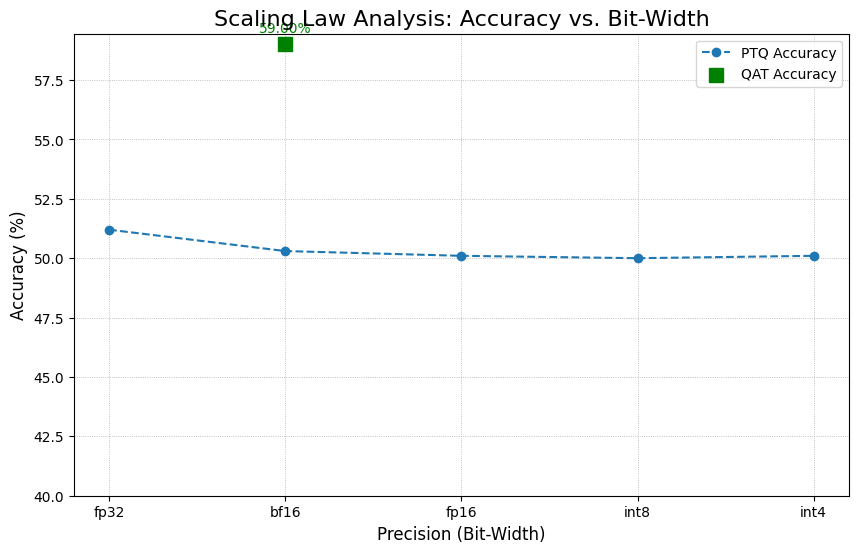

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Input Your Results ---
# PLEASE PASTE YOUR FP32 BASELINE ACCURACY HERE
# You can find this in your script output, e.g., "Baseline FP32 VGG-11 Accuracy: 51.20%"
try:
    fp32_baseline_acc = 51.20  # <--- !!! REPLACE THIS 51.20 with your actual baseline
except NameError:
    fp32_baseline_acc = np.nan # Handle if user forgets

# Your PTQ and QAT results
data = {
    'fp32': {'ptq_accuracy': fp32_baseline_acc, 'qat_accuracy': np.nan},
    'fp16': {'ptq_accuracy': 50.10, 'qat_accuracy': np.nan},
    'bf16': {'ptq_accuracy': 50.30, 'qat_accuracy': 59.0},
    'int8': {'ptq_accuracy': 50.00, 'qat_accuracy': np.nan},
    'int4': {'ptq_accuracy': 50.10, 'qat_accuracy': np.nan}
}

# --- Step 2: Prepare the DataFrame ---
df = pd.DataFrame(data).T
df.index.name = 'Precision'
df = df.reset_index()

# Clean up 'N/A' or 'nan' strings if they exist and convert to numeric
df['ptq_accuracy'] = pd.to_numeric(df['ptq_accuracy'], errors='coerce')
df['qat_accuracy'] = pd.to_numeric(df['qat_accuracy'], errors='coerce')

# Melt the DataFrame for easier plotting with matplotlib
df_melted = df.melt(id_vars='Precision', var_name='Method', value_name='Accuracy')

# Define the order for the x-axis (highest to lowest precision)
precision_order = ['fp32', 'bf16', 'fp16', 'int8', 'int4']
df_melted['Precision'] = pd.Categorical(df_melted['Precision'], categories=precision_order, ordered=True)
df_melted = df_melted.sort_values('Precision')

# Separate the data for plotting
ptq_data = df_melted[df_melted['Method'] == 'ptq_accuracy'].dropna()
qat_data = df_melted[df_melted['Method'] == 'qat_accuracy'].dropna()

# --- Step 3: Create the Plot ---
plt.figure(figsize=(10, 6))

# Plot PTQ
plt.plot(ptq_data['Precision'], ptq_data['Accuracy'], marker='o', linestyle='--', label='PTQ Accuracy')

# Plot QAT
# We only have one valid data point for QAT (bf16), so we'll plot it as a marker.
# If you had more QAT data, plt.plot() would connect them.
plt.scatter(qat_data['Precision'], qat_data['Accuracy'], marker='s', s=100, color='green', label='QAT Accuracy', zorder=5)

# --- Step 4: Customize the Plot ---
plt.title('Scaling Law Analysis: Accuracy vs. Bit-Width', fontsize=16)
plt.xlabel('Precision (Bit-Width)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle=':', linewidth=0.6)
plt.ylim(bottom=min(df_melted['Accuracy'].min()*0.9, 40)) # Set a reasonable y-axis floor

# Add text for the single QAT point
if not qat_data.empty:
    for i, row in qat_data.iterrows():
        plt.text(row['Precision'], row['Accuracy'] + 0.5, f"{row['Accuracy']:.2f}%", ha='center', color='green')

# Save the figure
plt.savefig('scaling_law_analysis.png', dpi=300, bbox_inches='tight')

print("Plot saved as 'scaling_law_analysis.png'")